# Monte Carlo Option Pricing — Analysis Notebook

End-to-end study of Monte Carlo methods for pricing derivative securities,
covering variance reduction, convergence analysis, path-dependent options,
quasi-Monte Carlo, Heston stochastic volatility, and finite-difference Greeks.

**Standard parameters used throughout:**

| Symbol | Value | Description |
|--------|-------|-------------|
| S0     | 100   | Spot price |
| K      | 100   | Strike (ATM) |
| T      | 1.0   | Maturity (years) |
| r      | 0.05  | Risk-free rate |
| σ      | 0.20  | Volatility |
| q      | 0.02  | Dividend yield |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

import os
FIGURES_DIR = os.path.join(os.path.dirname(os.path.abspath('__file__')), '..', 'figures')
# Use a direct path for robustness
FIGURES_DIR = '../figures'

# mc_pricer imports
from mc_pricer import RANDOM_SEED
from mc_pricer.analytics import (
    black_scholes_call, black_scholes_put,
    black_scholes_digital_call, asian_geometric_call,
    lookback_put_floating_analytic, barrier_down_and_out_call_analytic,
    implied_volatility, greeks,
)
from mc_pricer.processes import GeometricBrownianMotion, HestonProcess
from mc_pricer.payoffs import (
    european_call, european_put,
    asian_call_arithmetic, asian_call_geometric,
    barrier_down_and_out_call, lookback_put_floating, digital_call,
)
from mc_pricer.engines import MonteCarloEngine, MCResult
from mc_pricer.variance_reduction import (
    estimate_optimal_control_coefficient,
    stratified_sampling, latin_hypercube_sampling,
    compute_vrr_table,
)
from mc_pricer.quasi_random import SobolEngine, sobol_to_normal, discrepancy
from mc_pricer.benchmarks import ConvergenceBenchmark, fit_convergence_rate, plot_convergence

# Standard parameters
S0    = 100.0
K     = 100.0
T     = 1.0
R     = 0.05
SIGMA = 0.20
Q     = 0.02

# Engine
process = GeometricBrownianMotion(S0, mu=0.08, sigma=SIGMA, r=R, q=Q)
engine  = MonteCarloEngine(process, seed=RANDOM_SEED)

print(f'RANDOM_SEED = {RANDOM_SEED}')
print(f'S0={S0}, K={K}, T={T}, r={R}, sigma={SIGMA}, q={Q}')

RANDOM_SEED = 42
S0=100.0, K=100.0, T=1.0, r=0.05, sigma=0.2, q=0.02


---
## Section 1 — Theory

### 1.1  Risk-Neutral GBM

Under the risk-neutral measure $\mathbb{Q}$, the asset price follows:

$$dS_t = (r - q)\,S_t\,dt + \sigma\,S_t\,dW_t^\mathbb{Q}$$

Itô's lemma applied to $\log S_t$ gives the drift-adjusted SDE:

$$d(\log S_t) = \left(r - q - \tfrac{\sigma^2}{2}\right)dt + \sigma\,dW_t^\mathbb{Q}$$

which integrates **exactly** over any time step $\Delta t$:

$$S_{t+\Delta t} = S_t \exp\!\left[\left(r - q - \tfrac{\sigma^2}{2}\right)\Delta t + \sigma\sqrt{\Delta t}\,Z\right],\quad Z\sim\mathcal{N}(0,1)$$

### 1.2  Risk-Neutral Pricing

The no-arbitrage price of a derivative with payoff $\phi(S)$ is:

$$V_0 = e^{-rT}\,\mathbb{E}^\mathbb{Q}[\phi(S_T)]$$

Monte Carlo estimates this expectation by simulating $N$ independent paths and averaging:

$$\hat{V}_N = e^{-rT}\,\frac{1}{N}\sum_{i=1}^{N}\phi(S_T^{(i)})$$

### 1.3  CLT Convergence

By the Central Limit Theorem:

$$\mathrm{SE} = \frac{\sigma_{\phi}}{\sqrt{N}}, \qquad \mathrm{RMSE} = \mathcal{O}\!\left(N^{-1/2}\right)$$

where $\sigma_{\phi}^2 = \mathrm{Var}[\phi(S_T)]$.
A 95% confidence interval is $\hat{V}_N \pm 1.96\,\mathrm{SE}$.

### 1.4  Variance Reduction Methods

#### 1. Antithetic Variates
For each draw $Z$ generate the mirror $\tilde{Z} = -Z$ and average the paired payoffs:

$$\hat{f}_{\mathrm{anti}} = \tfrac{1}{2}\bigl(f(S(Z)) + f(S(-Z))\bigr)$$

$$\mathrm{Var}[\hat{f}_{\mathrm{anti}}] = \frac{\mathrm{Var}[f] + \mathrm{Cov}[f,\,\tilde{f}]}{2}$$

When $f$ is monotone in $S$ (e.g., call payoff), $\mathrm{Cov}[f,\tilde{f}]<0$, yielding variance reduction.

#### 2. Control Variates
Let $g$ be a correlated payoff with known mean $\mathbb{E}[g]$. The corrected estimator is:

$$f_{\mathrm{cv}} = f - b^*(g - \mathbb{E}[g]), \qquad b^* = \frac{\mathrm{Cov}(f,g)}{\mathrm{Var}(g)}$$

$$\mathrm{Var}[f_{\mathrm{cv}}] = \mathrm{Var}[f]\,(1 - \rho^2_{f,g})$$

#### 3. Importance Sampling
Shift the Brownian drift by $\theta$ (Girsanov's theorem). Under the tilted measure $\mathbb{Q}_\theta$:

$$\mathbb{E}^\mathbb{Q}[f(S)] = \mathbb{E}^{\mathbb{Q}_\theta}\!\left[f(S^\theta)\,\frac{d\mathbb{Q}}{d\mathbb{Q}_\theta}\right]$$

where the Radon-Nikodym derivative (likelihood ratio) is:

$$L = \frac{d\mathbb{Q}}{d\mathbb{Q}_\theta} = \exp\!\left(-\theta W_T^\theta - \tfrac{1}{2}\theta^2 T\right)$$

Choosing $\theta$ to concentrate paths near the payoff region reduces variance.

#### 4. Quasi-Monte Carlo / Sobol Sequences
Replace pseudo-random normals with low-discrepancy Sobol points. The **Koksma-Hlawka inequality** bounds the integration error:

$$|I_N[f] - I[f]| \leq V_{\mathrm{HK}}(f)\cdot D^*_N$$

For Sobol sequences (low-discrepancy), the star discrepancy satisfies:

$$D^*_N = \mathcal{O}\!\left(\frac{(\log N)^d}{N}\right)$$

which beats the pseudo-random rate $D^*_N = \mathcal{O}(N^{-1/2})$ for any fixed dimension $d$.

---
## Section 2 — European Option Validation

Compare all five MC methods against the Black-Scholes closed form for a European call.
Control variate uses the European put (with BS put price as $\mathbb{E}[g]$).
Importance sampling uses the optimal drift shift $\theta^*$.

In [2]:
N_PATHS = 20_000
N_STEPS = 50

# Black-Scholes reference prices
bs_call = black_scholes_call(S0, K, T, R, SIGMA, Q)
bs_put  = black_scholes_put(S0,  K, T, R, SIGMA, Q)

print(f'BS call = {bs_call:.6f}')
print(f'BS put  = {bs_put:.6f}')

# Optimal IS theta for a European call at strike K
# theta* = (log(K/S0) - (r - q - sigma^2/2)*T) / (sigma*sqrt(T))
theta_star = (np.log(K / S0) - (R - Q - 0.5 * SIGMA**2) * T) / (SIGMA * np.sqrt(T))
print(f'IS theta* = {theta_star:.4f}')

payoff_kw = dict(K=K, r=R)

# 1. Plain MC
res_plain = engine.price(european_call, T, N_STEPS, N_PATHS, **payoff_kw)

# 2. Antithetic
res_anti  = engine.price_antithetic(european_call, T, N_STEPS, N_PATHS, **payoff_kw)

# 3. Control variate (put as control)
res_cv    = engine.price_control_variate(
    european_call, european_put, bs_put,
    T, N_STEPS, N_PATHS, **payoff_kw
)

# 4. Importance sampling
res_is    = engine.price_importance_sampling(
    european_call, T, N_STEPS, N_PATHS, theta=theta_star, **payoff_kw
)

# 5. Quasi-MC (Sobol)
res_qmc   = engine.price_quasi_mc(european_call, T, N_STEPS, N_PATHS, **payoff_kw)

# Print comparison table
results_map = {
    'plain_mc':           res_plain,
    'antithetic':         res_anti,
    'control_variate':    res_cv,
    'importance_sampling': res_is,
    'quasi_mc':           res_qmc,
}

print(f'\n{"Method":<22} {"Price":>10} {"SE":>10} {"Error vs BS":>12}')
print('-' * 58)
for name, res in results_map.items():
    err = res.price - bs_call
    print(f'{name:<22} {res.price:>10.6f} {res.std_error:>10.6f} {err:>+12.6f}')
print(f'{"BS_call (exact)":<22} {bs_call:>10.6f} {"---":>10} {0.0:>+12.6f}')

BS call = 9.227006
BS put  = 6.330081
IS theta* = -0.0500



Method                      Price         SE  Error vs BS
----------------------------------------------------------
plain_mc                 9.166153   0.096840    -0.060853
antithetic               9.192496   0.072113    -0.034510
control_variate          9.169932   0.086251    -0.057073
importance_sampling      9.158012   0.102700    -0.068994
quasi_mc                 9.093646   0.096739    -0.133359
BS_call (exact)          9.227006        ---    +0.000000


In [3]:
# Variance Reduction Ratio table
vrr_df = compute_vrr_table(results_map, baseline_method='plain_mc')

print('\nVariance Reduction Ratio Table (baseline = plain MC):')
print(vrr_df.to_string(float_format='{:.6f}'.format))


Variance Reduction Ratio Table (baseline = plain MC):
                       price  std_error   variance      VRR
method                                                     
plain_mc            9.166153   0.096840 187.560918 1.000000
antithetic          9.192496   0.072113  52.002983 3.606734
control_variate     9.169932   0.086251 148.783895 1.260626
importance_sampling 9.158012   0.102700 210.946214 0.889141
quasi_mc            9.093646   0.096739 187.169862 1.002089


---
## Section 3 — Convergence Analysis

Empirical convergence rates for plain MC and antithetic variates.
We measure RMSE against the Black-Scholes call price over `n_repetitions=15`
independent runs per sample size, then fit $\mathrm{RMSE} \sim c \cdot N^\beta$ in log-log space.

Theory: $\beta = -0.5$ for plain MC, $\beta \leq -0.5$ for antithetic.

In [4]:
N_PATHS_LIST  = [100, 300, 1_000, 3_000, 10_000, 30_000]
N_REPETITIONS = 15
BS_CALL_PRICE = black_scholes_call(S0, K, T, R, SIGMA, Q)

bench_plain = ConvergenceBenchmark(
    engine=engine,
    payoff_fn=european_call,
    T=T,
    n_steps=N_STEPS,
    analytic_price=BS_CALL_PRICE,
    method='plain',
    payoff_kwargs=dict(K=K, r=R),
)

bench_anti = ConvergenceBenchmark(
    engine=engine,
    payoff_fn=european_call,
    T=T,
    n_steps=N_STEPS,
    analytic_price=BS_CALL_PRICE,
    method='antithetic',
    payoff_kwargs=dict(K=K, r=R),
)

print('Running plain MC convergence benchmark...')
df_plain = bench_plain.run(N_PATHS_LIST, n_repetitions=N_REPETITIONS, seed_offset=0)

print('Running antithetic convergence benchmark...')
df_anti  = bench_anti.run(N_PATHS_LIST, n_repetitions=N_REPETITIONS, seed_offset=500)

fit_plain = fit_convergence_rate(df_plain.groupby('n_paths')['rmse'].first().reset_index())
fit_anti  = fit_convergence_rate(df_anti.groupby('n_paths')['rmse'].first().reset_index())

print(f'\nPlain MC:   beta = {fit_plain["beta"]:+.3f},  R2 = {fit_plain["r2"]:.4f}')
print(f'Antithetic: beta = {fit_anti["beta"]:+.3f},  R2 = {fit_anti["r2"]:.4f}')

Running plain MC convergence benchmark...


Running antithetic convergence benchmark...



Plain MC:   beta = -0.469,  R2 = 0.9668
Antithetic: beta = -0.532,  R2 = 0.9952


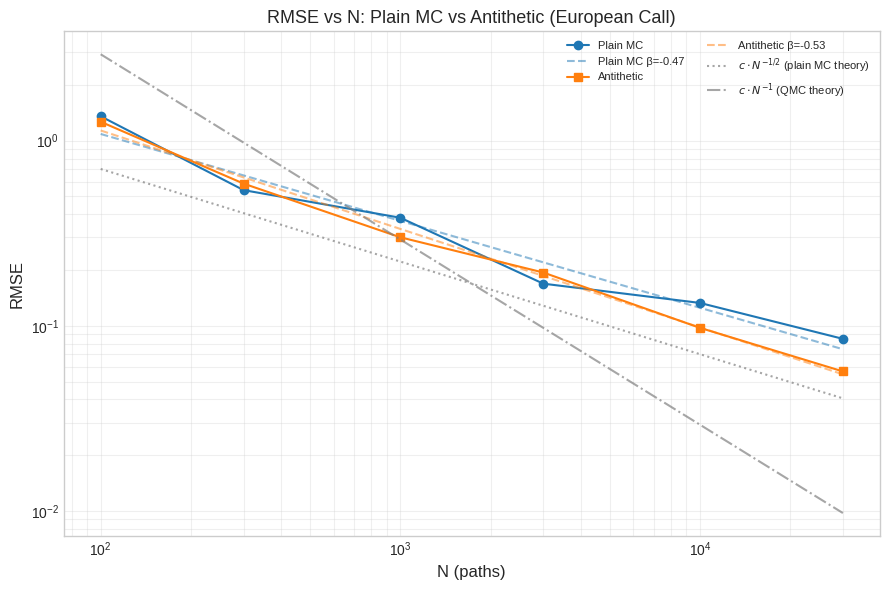

Figure saved to ../figures/convergence.png


In [5]:
# --- Log-log convergence plot ---
results_dict = {
    'Plain MC':   df_plain,
    'Antithetic': df_anti,
}

fig = plot_convergence(
    results_dict,
    analytic_price=BS_CALL_PRICE,
    title='RMSE vs N: Plain MC vs Antithetic (European Call)',
    figsize=(9, 6),
    save_path=f'{FIGURES_DIR}/convergence.png',
)
plt.show()
print(f'Figure saved to {FIGURES_DIR}/convergence.png')

In [6]:
# Summary table: N, RMSE(plain), RMSE(antithetic), fitted betas
rmse_plain = df_plain.groupby('n_paths')['rmse'].first().reset_index().rename(columns={'rmse': 'RMSE_plain'})
rmse_anti  = df_anti.groupby('n_paths')['rmse'].first().reset_index().rename(columns={'rmse': 'RMSE_anti'})
summary = rmse_plain.merge(rmse_anti, on='n_paths')
summary.columns = ['N', 'RMSE_plain', 'RMSE_antithetic']
summary['ratio'] = summary['RMSE_plain'] / summary['RMSE_antithetic']

print(summary.to_string(index=False, float_format='{:.6f}'.format))
print(f'\nFitted beta  — plain MC  : {fit_plain["beta"]:+.3f}  (theory: -0.500)')
print(f'Fitted beta  — antithetic: {fit_anti["beta"]:+.3f}  (theory: <= -0.500)')

    N  RMSE_plain  RMSE_antithetic    ratio
  100    1.352325         1.263167 1.070583
  300    0.539836         0.585288 0.922343
 1000    0.383031         0.300396 1.275089
 3000    0.168776         0.193859 0.870612
10000    0.132813         0.097448 1.362906
30000    0.084985         0.056674 1.499525

Fitted beta  — plain MC  : -0.469  (theory: -0.500)
Fitted beta  — antithetic: -0.532  (theory: <= -0.500)


---
## Section 4 — Path-Dependent Options

Pricing a suite of exotic options, each compared to its analytic benchmark where available.

In [7]:
# ── 4.1  Asian Arithmetic Call  (with Control Variate using Geometric Asian) ──

N_ASIAN  = 50_000
N_STEPS_ASIAN = 50

# Analytic price for geometric Asian (serves as control)
asian_geom_price = asian_geometric_call(S0, K, T, R, SIGMA, n_steps=N_STEPS_ASIAN, q=Q)

asian_kw = dict(K=K, r=R)

# Plain MC: arithmetic Asian
res_asian_plain = engine.price(asian_call_arithmetic, T, N_STEPS_ASIAN, N_ASIAN, **asian_kw)

# Control variate: arithmetic Asian with geometric Asian as control
res_asian_cv = engine.price_control_variate(
    asian_call_arithmetic, asian_call_geometric, asian_geom_price,
    T, N_STEPS_ASIAN, N_ASIAN, **asian_kw
)

vrr_asian = res_asian_plain.variance / res_asian_cv.variance if res_asian_cv.variance > 0 else float('nan')

print('Asian Arithmetic Call:')
print(f'  Plain MC:            {res_asian_plain.price:.6f}  SE={res_asian_plain.std_error:.6f}')
print(f'  Control Variate:     {res_asian_cv.price:.6f}  SE={res_asian_cv.std_error:.6f}  VRR={vrr_asian:.2f}')
print(f'  Geometric (analytic): {asian_geom_price:.6f}  [control reference, not arith price]')

Asian Arithmetic Call:
  Plain MC:            5.271976  SE=0.034234
  Control Variate:     5.208674  SE=0.000933  VRR=1347.25
  Geometric (analytic): 5.016630  [control reference, not arith price]


In [8]:
# ── 4.2  Barrier Down-and-Out Call  ──

B_BARRIER  = 90.0        # barrier level
N_BARRIER  = 50_000
N_STEPS_BAR = 252        # daily monitoring

barrier_kw = dict(K=K, B=B_BARRIER, r=R)

res_barrier = engine.price(barrier_down_and_out_call, T, N_STEPS_BAR, N_BARRIER, **barrier_kw)

analytic_barrier = barrier_down_and_out_call_analytic(S0, K, B_BARRIER, T, R, SIGMA, q=Q)

print('Down-and-Out Call (B=90):')
print(f'  MC (discrete, 252 steps): {res_barrier.price:.6f}  SE={res_barrier.std_error:.6f}')
print(f'  Analytic (continuous):    {analytic_barrier:.6f}')
print(f'  Discrete monitoring bias: {res_barrier.price - analytic_barrier:+.6f}')
print(f'  Note: discrete bias O(sigma*sqrt(T/n)) ~ {SIGMA * np.sqrt(T/N_STEPS_BAR):.5f}')

Down-and-Out Call (B=90):
  MC (discrete, 252 steps): 7.854292  SE=0.061534
  Analytic (continuous):    7.586954
  Discrete monitoring bias: +0.267338
  Note: discrete bias O(sigma*sqrt(T/n)) ~ 0.01260


In [9]:
# ── 4.3  Lookback Floating-Strike Put  ──

N_LOOKBACK   = 50_000
N_STEPS_LOOK = 500       # dense grid for small discrete bias

lb_kw = dict(r=R)

res_lookback = engine.price(lookback_put_floating, T, N_STEPS_LOOK, N_LOOKBACK, **lb_kw)

# GSG analytic (continuous time)
analytic_lookback = lookback_put_floating_analytic(S0, T, R, SIGMA, q=Q)

print('Lookback Floating-Strike Put:')
print(f'  MC (discrete, 500 steps): {res_lookback.price:.6f}  SE={res_lookback.std_error:.6f}')
print(f'  GSG analytic (contins.):  {analytic_lookback:.6f}')
print(f'  Expected GSG value ~14.29 (r=0.05, q=0, sigma=0.20)')
print(f'  Bias note: q={Q} shifts analytic price; GSG reference uses q=0')

# Reference at q=0 for the classic 14.29 benchmark
gsg_q0 = lookback_put_floating_analytic(S0, T, R, SIGMA, q=0.0)
print(f'  GSG analytic (q=0):       {gsg_q0:.6f}  [classic ~14.29]')

Lookback Floating-Strike Put:
  MC (discrete, 500 steps): 14.419245  SE=0.045088
  GSG analytic (contins.):  15.010268
  Expected GSG value ~14.29 (r=0.05, q=0, sigma=0.20)
  Bias note: q=0.02 shifts analytic price; GSG reference uses q=0
  GSG analytic (q=0):       14.290568  [classic ~14.29]


In [10]:
# ── 4.4  Digital Call: Plain MC vs Importance Sampling  ──

N_DIGITAL = 50_000
N_STEPS_DIG = 50

# Optimal IS theta for digital call (same as for vanilla call at ATM)
theta_dig = (np.log(K / S0) - (R - Q - 0.5 * SIGMA**2) * T) / (SIGMA * np.sqrt(T))

dig_kw = dict(K=K, r=R)

res_dig_plain = engine.price(digital_call, T, N_STEPS_DIG, N_DIGITAL, **dig_kw)
res_dig_is    = engine.price_importance_sampling(
    digital_call, T, N_STEPS_DIG, N_DIGITAL, theta=theta_dig, **dig_kw
)
analytic_dig = black_scholes_digital_call(S0, K, T, R, SIGMA, q=Q)

vrr_dig = res_dig_plain.variance / res_dig_is.variance if res_dig_is.variance > 0 else float('nan')

print('Digital Call:')
print(f'  Plain MC:          {res_dig_plain.price:.6f}  SE={res_dig_plain.std_error:.6f}')
print(f'  IS (theta={theta_dig:.3f}): {res_dig_is.price:.6f}  SE={res_dig_is.std_error:.6f}  VRR={vrr_dig:.2f}')
print(f'  BS analytic:       {analytic_dig:.6f}')

Digital Call:
  Plain MC:          0.495914  SE=0.002125
  IS (theta=-0.050): 0.495132  SE=0.002214  VRR=0.92
  BS analytic:       0.494581


In [11]:
# ── Summary Table ──
rows = [
    ('Asian arith. call (plain)',    res_asian_plain.price,   res_asian_plain.std_error,   None,              None),
    ('Asian arith. call (CV)',       res_asian_cv.price,      res_asian_cv.std_error,      None,              vrr_asian),
    ('Asian geom. call (analytic)',  asian_geom_price,        None,                        asian_geom_price,  None),
    ('Barrier DOC (MC disc.)',       res_barrier.price,       res_barrier.std_error,       analytic_barrier,  None),
    ('Lookback float put',           res_lookback.price,      res_lookback.std_error,      gsg_q0,            None),
    ('Digital call (plain)',         res_dig_plain.price,     res_dig_plain.std_error,     analytic_dig,      None),
    ('Digital call (IS)',            res_dig_is.price,        res_dig_is.std_error,        analytic_dig,      vrr_dig),
]

print(f'{"Option":<32} {"MC Price":>10} {"SE":>8} {"Analytic":>10} {"Error":>10} {"VRR":>6}')
print('-' * 80)
for (name, price, se, analytic, vrr) in rows:
    se_str  = f'{se:.6f}'      if se      is not None else '      ---'
    ana_str = f'{analytic:.6f}' if analytic is not None else '       ---'
    err_str = f'{price - analytic:+.6f}' if analytic is not None else '         ---'
    vrr_str = f'{vrr:.2f}'    if vrr     is not None else ' ---'
    print(f'{name:<32} {price:>10.6f} {se_str:>8} {ana_str:>10} {err_str:>10} {vrr_str:>6}')

Option                             MC Price       SE   Analytic      Error    VRR
--------------------------------------------------------------------------------
Asian arith. call (plain)          5.271976 0.034234        ---          ---    ---
Asian arith. call (CV)             5.208674 0.000933        ---          --- 1347.25
Asian geom. call (analytic)        5.016630       ---   5.016630  +0.000000    ---
Barrier DOC (MC disc.)             7.854292 0.061534   7.586954  +0.267338    ---
Lookback float put                14.419245 0.045088  14.290568  +0.128677    ---
Digital call (plain)               0.495914 0.002125   0.494581  +0.001333    ---
Digital call (IS)                  0.495132 0.002214   0.494581  +0.000551   0.92


---
## Section 5 — QMC Deep Dive

Visual comparison of Sobol (scrambled) vs pseudo-random point distributions,
and empirical star discrepancy $D^*_N$ vs sample size $N$.

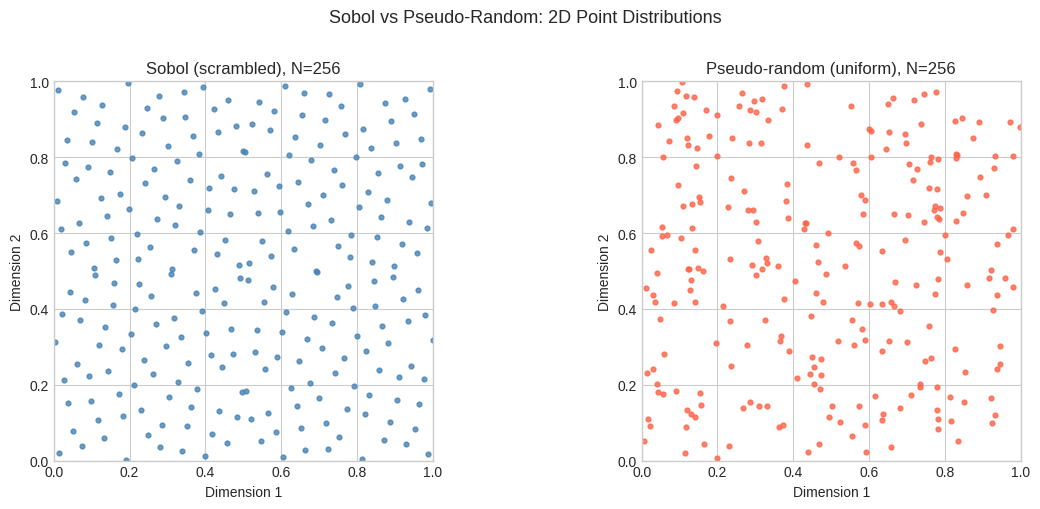

Note: Sobol fills the unit square more uniformly (avoids clustering and gaps).


In [12]:
N_SCATTER = 256

# Sobol 2D points
sobol_eng = SobolEngine(dimension=2, scramble=True, seed=RANDOM_SEED)
sobol_pts = sobol_eng.random(N_SCATTER)    # shape (256, 2), in [0,1)

# Pseudo-random 2D points
rng_pr = np.random.default_rng(RANDOM_SEED)
rand_pts = rng_pr.uniform(0.0, 1.0, size=(N_SCATTER, 2))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(sobol_pts[:, 0], sobol_pts[:, 1], s=12, alpha=0.8, color='steelblue')
axes[0].set_title(f'Sobol (scrambled), N={N_SCATTER}', fontsize=12)
axes[0].set_xlabel('Dimension 1')
axes[0].set_ylabel('Dimension 2')
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].set_aspect('equal')

axes[1].scatter(rand_pts[:, 0], rand_pts[:, 1], s=12, alpha=0.8, color='tomato')
axes[1].set_title(f'Pseudo-random (uniform), N={N_SCATTER}', fontsize=12)
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')
axes[1].set_xlim(0, 1)
axes[1].set_ylim(0, 1)
axes[1].set_aspect('equal')

fig.suptitle('Sobol vs Pseudo-Random: 2D Point Distributions', fontsize=13, y=1.01)
fig.tight_layout()
plt.show()
print('Note: Sobol fills the unit square more uniformly (avoids clustering and gaps).')

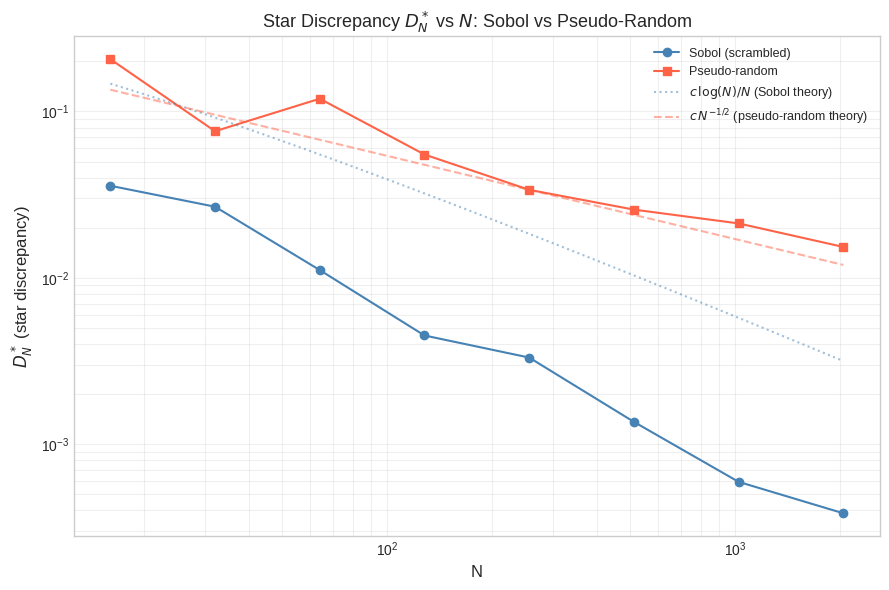

Figure saved to ../figures/sobol_discrepancy.png


In [13]:
# D*_N vs N (log-log) for Sobol and pseudo-random
N_powers = [2**k for k in range(4, 12)]   # 16, 32, ..., 2048

disc_sobol = []
disc_rand  = []

sobol_1d = SobolEngine(dimension=1, scramble=True, seed=RANDOM_SEED)
rng_disc = np.random.default_rng(RANDOM_SEED)

for N in N_powers:
    sobol_1d.reset()
    u_sob  = sobol_1d.random(N)[:, 0]
    u_rand = rng_disc.uniform(0.0, 1.0, N)
    disc_sobol.append(discrepancy(u_sob))
    disc_rand.append(discrepancy(u_rand))

N_arr = np.array(N_powers, dtype=float)

fig, ax = plt.subplots(figsize=(9, 6))
ax.loglog(N_arr, disc_sobol, 'o-', color='steelblue', label='Sobol (scrambled)')
ax.loglog(N_arr, disc_rand,  's-', color='tomato',    label='Pseudo-random')

# Reference slopes
n_ref = np.logspace(np.log10(N_arr[0]), np.log10(N_arr[-1]), 100)
anchor = disc_sobol[len(disc_sobol) // 2]
n_mid  = N_arr[len(N_arr) // 2]
ax.loglog(n_ref, anchor * (n_ref / n_mid)**(-1.0) * np.log(n_ref),
          ':', color='steelblue', alpha=0.5, label=r'$c\,\log(N)/N$ (Sobol theory)')
ax.loglog(n_ref, disc_rand[len(disc_rand) // 2] * (n_ref / n_mid)**(-0.5),
          '--', color='tomato', alpha=0.5, label=r'$c\,N^{-1/2}$ (pseudo-random theory)')

ax.set_xlabel('N', fontsize=12)
ax.set_ylabel(r'$D^*_N$ (star discrepancy)', fontsize=12)
ax.set_title(r'Star Discrepancy $D^*_N$ vs $N$: Sobol vs Pseudo-Random', fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/sobol_discrepancy.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Figure saved to {FIGURES_DIR}/sobol_discrepancy.png')

---
## Section 6 — Heston Stochastic Volatility Model

The Heston (1993) model adds mean-reverting stochastic variance:

$$dS_t = r\,S_t\,dt + \sqrt{v_t}\,S_t\,dW_t^S$$
$$dv_t = \kappa(\bar{\theta} - v_t)\,dt + \xi\,\sqrt{v_t}\,dW_t^v, \qquad \mathrm{Corr}(dW^S, dW^v) = \rho\,dt$$

Parameters chosen to exhibit realistic volatility clustering and leverage effect ($\rho < 0$).

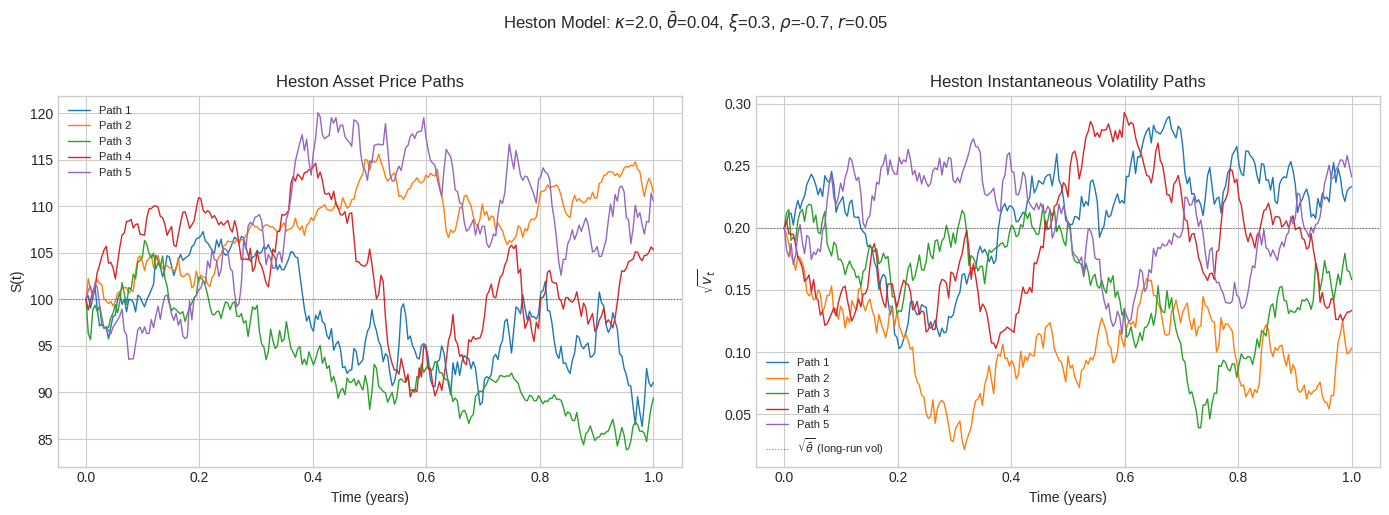

Figure saved to ../figures/heston_paths.png

Feller condition: 2*kappa*theta = 0.160,  xi^2 = 0.090


In [14]:
heston = HestonProcess(
    S0=100.0,
    v0=0.04,
    kappa=2.0,
    theta=0.04,
    xi=0.3,
    rho=-0.7,
    r=0.05,
)

N_HESTON_PATHS = 5
N_HESTON_STEPS = 252
rng_heston = np.random.default_rng(RANDOM_SEED)

S_paths, v_paths = heston.simulate(
    T=1.0, n_steps=N_HESTON_STEPS, n_paths=N_HESTON_PATHS, rng=rng_heston
)

t_grid = np.linspace(0.0, 1.0, N_HESTON_STEPS + 1)
vol_paths = np.sqrt(np.maximum(v_paths, 0.0))   # instantaneous vol

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_h = plt.rcParams['axes.prop_cycle'].by_key()['color']
for i in range(N_HESTON_PATHS):
    axes[0].plot(t_grid, S_paths[i], color=colors_h[i % len(colors_h)], linewidth=1.0, label=f'Path {i+1}')
    axes[1].plot(t_grid, vol_paths[i], color=colors_h[i % len(colors_h)], linewidth=1.0, label=f'Path {i+1}')

axes[0].axhline(100.0, color='black', linestyle=':', linewidth=0.8, alpha=0.5)
axes[0].set_title('Heston Asset Price Paths', fontsize=12)
axes[0].set_xlabel('Time (years)')
axes[0].set_ylabel('S(t)')
axes[0].legend(fontsize=8)

axes[1].axhline(np.sqrt(heston.theta), color='black', linestyle=':', linewidth=0.8, alpha=0.5,
                label=r'$\sqrt{\bar{\theta}}$ (long-run vol)')
axes[1].set_title('Heston Instantaneous Volatility Paths', fontsize=12)
axes[1].set_xlabel('Time (years)')
axes[1].set_ylabel(r'$\sqrt{v_t}$')
axes[1].legend(fontsize=8)

fig.suptitle(
    r'Heston Model: $\kappa$=2.0, $\bar{\theta}$=0.04, $\xi$=0.3, $\rho$=-0.7, $r$=0.05',
    fontsize=12, y=1.02
)
fig.tight_layout()
fig.savefig(f'{FIGURES_DIR}/heston_paths.png', dpi=300, bbox_inches='tight')
plt.show()
print(f'Figure saved to {FIGURES_DIR}/heston_paths.png')
print(f'\nFeller condition: 2*kappa*theta = {2*heston.kappa*heston.theta:.3f},  xi^2 = {heston.xi**2:.3f}')

---
## Section 7 — Greeks via Monte Carlo

Greeks are estimated by **finite differences** of the MC price:

$$\Delta \approx \frac{V(S_0+h) - V(S_0-h)}{2h}, \quad h = 0.01\,S_0$$

$$\Gamma \approx \frac{V(S_0+h) - 2V(S_0) + V(S_0-h)}{h^2}$$

$$\mathcal{V} \approx \frac{V(\sigma+\epsilon) - V(\sigma-\epsilon)}{2\epsilon}, \quad \epsilon = 0.001$$

All three FD estimates are compared to the analytical Black-Scholes Greeks.

In [15]:
N_GREEKS = 50_000
N_STEPS_GR = 50
h  = 0.01 * S0      # bump for delta / gamma
eps = 0.001          # bump for vega

def make_engine(s0, sigma_val):
    """Helper: build a new engine with bumped S0 or sigma."""
    proc = GeometricBrownianMotion(s0, mu=0.08, sigma=sigma_val, r=R, q=Q)
    return MonteCarloEngine(proc, seed=RANDOM_SEED)

kw = dict(K=K, r=R)

# Prices at S0, S0+h, S0-h  (same sigma)
price_base  = engine.price(european_call, T, N_STEPS_GR, N_GREEKS, **kw).price
price_up    = make_engine(S0 + h,  SIGMA).price(european_call, T, N_STEPS_GR, N_GREEKS, **kw).price
price_down  = make_engine(S0 - h,  SIGMA).price(european_call, T, N_STEPS_GR, N_GREEKS, **kw).price

# Prices at sigma+eps, sigma-eps  (same S0)
price_vup   = make_engine(S0, SIGMA + eps).price(european_call, T, N_STEPS_GR, N_GREEKS, **kw).price
price_vdown = make_engine(S0, SIGMA - eps).price(european_call, T, N_STEPS_GR, N_GREEKS, **kw).price

# MC Greeks
delta_mc = (price_up - price_down) / (2.0 * h)
gamma_mc = (price_up - 2.0 * price_base + price_down) / (h**2)
vega_mc  = (price_vup - price_vdown) / (2.0 * eps)

# Analytical Greeks
bs_greeks = greeks(S0, K, T, R, SIGMA, q=Q)

print(f'{"Greek":<8} {"MC (FD)":>12} {"BS Analytic":>12} {"Error":>10}')
print('-' * 46)
for greek_name, mc_val, bs_val in [
    ('Delta', delta_mc, bs_greeks['Delta']),
    ('Gamma', gamma_mc, bs_greeks['Gamma']),
    ('Vega',  vega_mc,  bs_greeks['Vega']),
]:
    err = mc_val - bs_val
    print(f'{greek_name:<8} {mc_val:>12.6f} {bs_val:>12.6f} {err:>+10.6f}')

Greek         MC (FD)  BS Analytic      Error
----------------------------------------------
Delta        0.588195     0.586851  +0.001344
Gamma        0.019552     0.018951  +0.000601
Vega        37.884220    37.901158  -0.016937


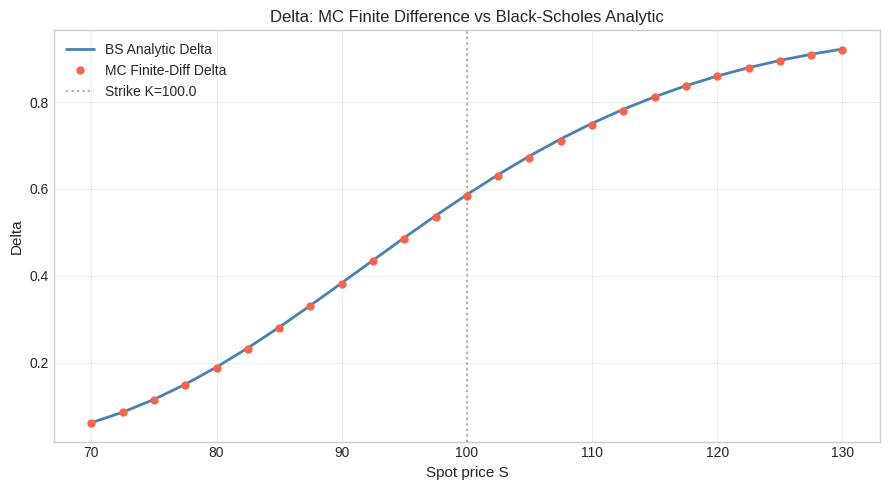

In [16]:
# Visualise: Delta sensitivity around ATM
S_range = np.linspace(70, 130, 25)
h_vis   = 0.01 * S0

delta_mc_arr = []
delta_bs_arr = []

for s in S_range:
    p_up   = make_engine(s + h_vis, SIGMA).price(european_call, T, N_STEPS_GR, 10_000, **kw).price
    p_down = make_engine(s - h_vis, SIGMA).price(european_call, T, N_STEPS_GR, 10_000, **kw).price
    delta_mc_arr.append((p_up - p_down) / (2.0 * h_vis))
    delta_bs_arr.append(greeks(s, K, T, R, SIGMA, q=Q)['Delta'])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(S_range, delta_bs_arr, '-', color='steelblue', linewidth=2, label='BS Analytic Delta')
ax.plot(S_range, delta_mc_arr, 'o', color='tomato', markersize=5, label='MC Finite-Diff Delta')
ax.axvline(K, color='grey', linestyle=':', alpha=0.6, label=f'Strike K={K}')
ax.set_xlabel('Spot price S', fontsize=11)
ax.set_ylabel('Delta', fontsize=11)
ax.set_title('Delta: MC Finite Difference vs Black-Scholes Analytic', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

---
## Section 8 — Limitations and Caveats

- **QMC curse of dimensionality:** Sobol sequences retain low discrepancy only for a limited effective dimension. This implementation uses the Joe & Kuo (2010) direction numbers, which support at most **21 dimensions**. For path-dependent options requiring many time steps (e.g., n_steps > 21), the engine pads remaining dimensions with pseudo-random normals, degrading the $\mathcal{O}((\log N)^d/N)$ convergence guarantee. In practice, Brownian bridge construction or principal component analysis of the covariance structure can reduce the effective dimension.

- **IS weight degeneracy:** Importance sampling concentrates simulation effort near the payoff-relevant region by shifting the drift by $\theta$. However, a poorly chosen $\theta$ can make the likelihood-ratio weights $L = \exp(-\theta W_T - \tfrac{1}{2}\theta^2 T)$ highly variable, inflating the estimator variance by a factor of $\exp(\theta^2 T)$. This pathology manifests when $|\theta|$ is large relative to the payoff support, leading to a few paths with enormous weights dominating the estimator.

- **Discrete barrier/lookback bias:** Barrier and lookback options use discrete monitoring (checking only at simulated time steps). The analytic formulas assume continuous monitoring. The resulting systematic underestimation bias for barrier options is of order $\mathcal{O}(\sigma\sqrt{T/n})$, where $n$ is the number of monitoring dates. For the parameters used here ($\sigma=0.20$, $T=1$, $n=252$), this amounts to approximately $0.20/\sqrt{252} \approx 0.013$. Continuity corrections (Broadie, Glasserman & Kou 1997) can mitigate this bias analytically.

- **GBM constant volatility:** The Black-Scholes/GBM framework assumes constant $\sigma$, which contradicts the empirically observed volatility smile/skew. The Heston model adds mean-reverting stochastic variance $v_t$, capturing volatility clustering and the leverage effect ($\rho < 0$). However, Heston is still a stylised model: it cannot reproduce the full term-structure of the smile, jumps in asset returns, or regime-switching behaviour observed in real markets.